
# Analyze National Water Model Streamflow vs USGS Observations Using HUC-Based Site Selection

Authors: Anthony Castronova (acastronova@cuahsi.org), Irene Garousi-Nejad (igarousi@cuahsi.org), Danielle Tijerina-Kreuzer (dtijerina@cuahsi.org)  
Last updated: Mar 27, 2026

#### Introduction

This notebook demonstrates a **point-scale streamflow evaluation workflow** for the NOAA National Water Model (NWM) retrospective dataset using **HydroData HUC-based queries** to identify USGS streamflow gauges. The workflow follows the same general structure as the watershed notebook, but instead of reading a local shapefile, it uses a Hydrologic Unit Code (HUC) to define the study area.

The notebook will:

1. Use a HUC identifier to discover USGS streamflow gauges through HydroData.
2. Request gauge metadata and plot the selected sites on an interactive map.
3. Retrieve daily USGS streamflow observations from HydroData.
4. Retrieve matching NWM retrospective streamflow from `chrtout.zarr`.
5. Compare observed and modeled streamflow at selected gauges and compute evaluation metrics.

## 1. Setup

### 1a. Python Environment

Ensure that the `cssi_evaluation` conda environment is selected as your Jupyter kernel. This environment should already be available if you followed the repository setup instructions.

Import the libraries needed to run this notebook:

In [4]:
import os
import sys
from pathlib import Path

import geopandas as gpd
import holoviews as hv
import hvplot.pandas
import hf_hydrodata as hf
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from dask.distributed import Client

repo_root = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(repo_root / 'src'))

from cssi_evaluation.models import nwm_utils
from cssi_evaluation.utils import evaluation_utils, metric_utils, plot_utils

hv.extension('bokeh')

%load_ext autoreload
%autoreload 2

### 1b. HydroData Registration

You need a HydroData account and API PIN before requesting USGS observations. Replace the placeholder values in the next cell with your HydroData credentials.

In [5]:
# hf.register_api_pin('your_email', 'your_api_pin')
hf.register_api_pin('igarousi@cuahsi.org', '9090')

### 1c. Dask

We use Dask to parallelize access to the large NWM Zarr store. Adjust the number of workers and memory settings to match your workstation if needed.

In [6]:
try:
    print('Dashboard link:', client.dashboard_link)
except NameError:
    client = Client(n_workers=6, threads_per_worker=1, memory_limit='2GB')
    print('Dashboard link:', client.dashboard_link)

print(client)

/opt/anaconda3/envs/cssi_evaluation/lib/python3.10/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 55902 instead
  warnings.warn(


Dashboard link: http://127.0.0.1:55902/status
<Client: 'tcp://127.0.0.1:55903' processes=6 threads=6, memory=11.18 GiB>


### 1d. Set Paths and Parameters

In [7]:
repo_root = Path.cwd().resolve().parents[1]

huc_id = ['02030105']
start_date = '2018-10-01'
end_date = '2020-09-30'

# NWM retrospective v3.0 channel routing output
conus_bucket_url = 's3://noaa-nwm-retrospective-3-0-pds/CONUS/zarr/chrtout.zarr'

# Optional location to save modeled streamflow data retrieved from NWM
MOD_OutputFolder = './mod_outputs_NWM_streamflow_huc'

# HydroData request settings for daily USGS streamflow
hydrodata_options = {
    'dataset': 'usgs_nwis',
    'variable': 'streamflow',
    'temporal_resolution': 'daily',
    'aggregation': 'mean',
    'grid': 'conus2',
    'date_start': start_date,
    'date_end': end_date,
    'huc_id': huc_id,
}

## 2. Retrieve Observed USGS Streamflow from HydroData

Use HydroData to explore which USGS daily streamflow sites are available within the selected HUC for the requested time period. This query defines the study area directly from the HUC rather than from a local watershed shapefile.

In [8]:
available_sites_df = hf.get_site_variables(
    variable='streamflow',
    agency='USGS',
    temporal_resolution='daily',
    grid='conus2',
    date_start=start_date,
    date_end=end_date,
    huc_id=huc_id,
)

print(f'Number of HydroData availability records in HUC {huc_id[0]}: {len(available_sites_df)}')
available_sites_df.head()

Number of HydroData availability records in HUC 02030105: 22


,site_id,site_name,site_type,agency,state,variable_name,units,dataset,variable,temporal_resolution,...,latitude,longitude,site_query_url,date_metadata_last_updated,tz_cd,doi,conus1_i,conus1_j,conus2_i,conus2_j
0,01396500,South Branch Raritan River near High Bridge NJ,stream gauge,USGS,NJ,Daily average streamflow,m3/s,usgs_nwis,streamflow,daily,...,40.677778,-74.879167,https://api.waterdata.usgs.gov/ogcapi/v0/colle...,2025-12-02,EST,None,None,None,3993.0,1993.0
1,01396660,Mulhockaway Creek at Van Syckel NJ,stream gauge,USGS,NJ,Daily average streamflow,m3/s,usgs_nwis,streamflow,daily,...,40.647500,-74.968889,https://api.waterdata.usgs.gov/ogcapi/v0/colle...,2025-12-02,EST,None,None,None,3987.0,1985.0
2,01396800,Spruce Run at Clinton NJ,stream gauge,USGS,NJ,Daily average streamflow,m3/s,usgs_nwis,streamflow,daily,...,40.640000,-74.915556,https://api.waterdata.usgs.gov/ogcapi/v0/colle...,2025-12-02,EST,None,None,None,3991.0,1985.0
3,01397000,South Branch Raritan River at Stanton NJ,stream gauge,USGS,NJ,Daily average streamflow,m3/s,usgs_nwis,streamflow,daily,...,40.572222,-74.868056,https://api.waterdata.usgs.gov/ogcapi/v0/colle...,2025-12-02,EST,None,None,None,3996.0,1980.0
4,01398000,Neshanic River at Reaville NJ,stream gauge,USGS,NJ,Daily average streamflow,m3/s,usgs_nwis,streamflow,daily,...,40.473333,-74.827778,https://api.waterdata.usgs.gov/ogcapi/v0/colle...,2025-12-02,EST,None,None,None,4004.0,1969.0


The HydroData site table includes latitude and longitude coordinates, so we can plot the candidate stream gauges directly from those coordinates using a shared site-mapping utility in `plot_utils.py`.

In [9]:
plot_utils.map_sites_from_latlon(available_sites_df, zoom_start=8)

Request the full metadata for the USGS streamflow gauges in the selected HUC, convert the result to a GeoDataFrame for consistency with the rest of the workflow, and sort the stations by site ID.

In [10]:
obs_metadata_df = hf.get_point_metadata(**hydrodata_options)

obs_sites_gdf = gpd.GeoDataFrame(
    obs_metadata_df.copy(),
    geometry=gpd.points_from_xy(obs_metadata_df.longitude, obs_metadata_df.latitude),
    crs='EPSG:4326',
)

obs_sites_gdf = obs_sites_gdf.sort_values('site_id').reset_index(drop=True)

print(f'Number of USGS streamflow gauges in HUC {huc_id[0]}: {len(obs_sites_gdf)}')
obs_sites_gdf[['site_id', 'site_name', 'latitude', 'longitude']].head()

Number of USGS streamflow gauges in HUC 02030105: 22


,site_id,site_name,latitude,longitude
0,01396500,South Branch Raritan River near High Bridge NJ,40.677778,-74.879167
1,01396660,Mulhockaway Creek at Van Syckel NJ,40.647500,-74.968889
2,01396800,Spruce Run at Clinton NJ,40.640000,-74.915556
3,01397000,South Branch Raritan River at Stanton NJ,40.572222,-74.868056
4,01398000,Neshanic River at Reaville NJ,40.473333,-74.827778


Create a list of the final USGS site IDs in the selected HUC and use that list to request the observed streamflow time series from HydroData. The returned data are then formatted so they are ready for comparison with the NWM results.

In [12]:
site_ids = obs_sites_gdf['site_id'].astype(str).tolist()

obs_df = hf.get_point_data(
    **hydrodata_options,
    site_ids=site_ids,
)

obs_df['date'] = pd.to_datetime(obs_df['date'])
obs_df = obs_df.sort_values('date')
obs_df.head()

,date,01396500,01396660,01396800,01397000,01398000,01398500,01399100,01399500,01399670,...,01402000,01402630,01403060,01403150,01403400,01403540,01403900,01405030,01405400,01406050
0,2018-10-01,4.5846,0.45563,2.72812,10.2446,1.18860,1.63008,0.229230,3.31110,0.46978,...,14.6877,0.241682,42.450,0.032545,0.176875,0.172913,1.75460,0.93673,1.90459,0.60562
1,2018-10-02,4.2167,0.76127,3.96200,11.1502,1.04427,1.70366,0.243946,2.88660,0.44997,...,9.4805,0.205741,33.960,0.121124,0.424500,0.418840,1.65838,0.65656,1.72630,0.50374
2,2018-10-03,9.2824,0.88862,3.96200,17.9705,1.86214,3.31110,0.636750,3.19790,0.86598,...,12.3388,0.566000,54.053,0.082919,0.455630,0.435820,5.23550,1.55933,2.04326,0.83202
3,2018-10-04,4.9808,0.46412,3.96200,12.3388,0.93390,1.66687,0.195553,2.49323,0.42733,...,10.6691,0.178573,38.205,0.035092,0.207439,0.188195,1.83950,0.70184,1.93855,0.59147
4,2018-10-05,4.0186,0.39620,3.96200,10.8389,0.76976,1.50273,0.156782,2.35739,0.37639,...,7.8674,0.131312,28.866,0.029715,0.201496,0.151971,1.47726,0.48393,1.61593,0.45846


## 3. Retrieve Streamflow Model Outputs

NOAA shares inputs and outputs for the National Water Model retrospective simulations version 3 at <a href="https://noaa-nwm-retrospective-3-0-pds.s3.amazonaws.com/index.html" style="color: blue; background-color: snow;">https://noaa-nwm-retrospective-3-0-pds.s3.amazonaws.com/index.html</a>. In this notebook, we use the `chrtout.zarr` store, which contains streamflow at routed channel locations.

To keep the workflow consistent with the other streamflow notebook, we call a helper function in `cssi_evaluation.models.nwm_utils` that retrieves NWM streamflow for all filtered USGS gauges and returns a single wide dataframe with one column per site.

In [13]:
# Create a folder to save modeled NWM streamflow outputs
if not os.path.exists(MOD_OutputFolder):
    os.mkdir(MOD_OutputFolder)

Note that the `nwm_utils.getNWMQ` function is currently matching on `gage_id`, not on location. That means it only retrieves NWM streamflow for the subset of USGS gauges in the HUC that are explicitly linked to NWM gage identifiers in the channel-routing dataset.

In [14]:
%%time
model_df = nwm_utils.getNWMQ(
    obs_sites_gdf,
    conus_bucket_url,
    start_date,
    end_date,
    f'{MOD_OutputFolder}/mod_nwm_streamflow_data.csv',
)

Matched 22 NWM gauges out of 22 requested.

Saved modeled streamflow data to: ./mod_outputs_NWM_streamflow_huc/mod_nwm_streamflow_data.csv
CPU times: user 3.13 s, sys: 825 ms, total: 3.96 s
Wall time: 53 s


In [15]:
model_df.head()

,date,01396500,01396660,01396800,01397000,01398000,01398500,01399100,01399500,01399670,...,01402000,01402630,01403060,01403150,01403400,01403540,01403900,01405030,01405400,01406050
0,2018-10-01 00:00:00,7.23,1.56,1.24,12.93,1.31,2.49,0.79,3.34,1.06,...,65.559999,1.88,138.449997,0.38,0.75,1.45,11.34,6.13,5.12,2.97
1,2018-10-01 01:00:00,7.27,1.52,1.24,12.77,1.31,2.46,0.77,3.36,1.03,...,65.149999,1.88,136.969997,0.31,0.73,1.32,11.13,5.95,5.00,2.92
2,2018-10-01 02:00:00,6.97,1.52,1.24,12.65,1.31,2.40,0.59,3.57,1.00,...,64.679999,1.89,135.499997,0.34,0.80,1.28,10.93,5.95,4.75,2.73
3,2018-10-01 03:00:00,6.87,1.57,1.24,12.49,1.31,2.32,0.61,3.90,1.02,...,64.169999,1.89,134.029997,0.35,0.80,1.27,10.75,5.73,5.25,2.58
4,2018-10-01 04:00:00,6.79,1.54,1.24,12.37,1.32,2.84,0.52,3.28,1.02,...,63.729999,1.89,132.639997,0.35,0.78,1.28,10.55,5.71,5.42,2.45


Identify the sites that are present in **both the observed HydroData table and the modeled NWM table**, then subset the observation data, model data, and station metadata to that shared set of gauges. This ensures that all later comparisons and metric calculations use only sites for which both observed and modeled streamflow are available.

In [25]:
common_site_ids = sorted(set(obs_df.columns[1:]).intersection(model_df.columns[1:]))

obs_df_common = obs_df[['date'] + common_site_ids].copy()
model_df_common = model_df[['date'] + common_site_ids].copy()
metadata_common = obs_sites_gdf[obs_sites_gdf['site_id'].astype(str).isin(common_site_ids)].copy()

print(f'Number of sites available in both HydroData and NWM: {len(common_site_ids)}')
common_site_ids[:10]

Number of sites available in both HydroData and NWM: 22


['01396500',
 '01396660',
 '01396800',
 '01397000',
 '01398000',
 '01398500',
 '01399100',
 '01399500',
 '01399670',
 '01400000']

## 4. Quick Plot Sanity Check

Plot one gauge to confirm that both observation and model retrieval steps worked as expected. Set `my_site_id` to any gauge listed in `common_site_ids`.

In [26]:
my_site_id = common_site_ids[0]

comparison_df = pd.merge(
    obs_df_common[['date', my_site_id]],
    model_df_common[['date', my_site_id]],
    on='date',
    how='inner',
    suffixes=('_obs', '_nwm'),
).set_index('date')

comparison_df.head()

,01396500_obs,01396500_nwm
date,,
2018-10-01,4.5846,7.23
2018-10-02,4.2167,5.63
2018-10-03,9.2824,4.60
2018-10-04,4.9808,10.26
2018-10-05,4.0186,5.19


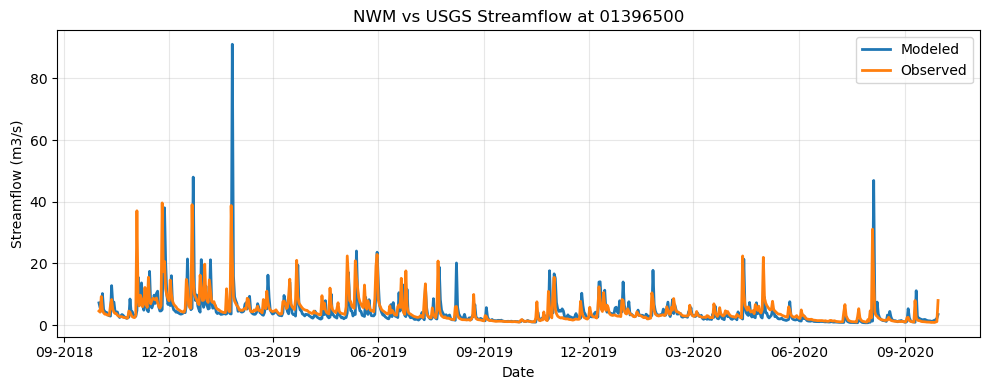

In [27]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(comparison_df.index, comparison_df[f'{my_site_id}_nwm'], label='Modeled', linewidth=2)
ax.plot(comparison_df.index, comparison_df[f'{my_site_id}_obs'], label='Observed', linewidth=2)

ax.set_xlabel('Date')
ax.set_ylabel('Streamflow (m3/s)')
ax.set_title(f'NWM vs USGS Streamflow at {my_site_id}')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()

## 5. Compute Statistics and Error Metrics

The evaluation utilities expect both the observed and modeled data in wide format with a leading `date` column and matching site columns. After aligning the two tables on common dates, we can compute site-level metrics for all gauges available in both datasets.

In [28]:
obs_eval = obs_df_common.copy()
model_eval = model_df_common.copy()

common_dates = sorted(set(obs_eval['date']).intersection(model_eval['date']))
obs_eval = obs_eval[obs_eval['date'].isin(common_dates)].sort_values('date').reset_index(drop=True)
model_eval = model_eval[model_eval['date'].isin(common_dates)].sort_values('date').reset_index(drop=True)

metadata_eval = metadata_common[['site_id', 'site_name', 'latitude', 'longitude']].copy()
metadata_eval['site_id'] = metadata_eval['site_id'].astype(str)

print(obs_eval.shape, model_eval.shape, metadata_eval.shape)

(731, 23) (731, 23) (22, 4)


Use the `evaluation_utils.calculate_metrics()` function to compute the full set of evaluation metrics for all gauges shared between the observed and modeled datasets. This function compares the HydroData streamflow observations and NWM streamflow simulations site by site, and returns the results in `metrics_df`, where each row corresponds to one gauge and each column contains a performance metric.

In [29]:
metrics_df = evaluation_utils.calculate_metrics(
    obs_eval,
    model_eval,
    metadata_eval,
    metrics_list=None,
    write_csv=False,
    csv_path=None,
)

metrics_df.head()

,site_id,site_name,latitude,longitude,rmse,mse,pearson_r,spearman_rho,nse,kge,r_squared,bias_from_r,bias,percent_bias,abs_rel_bias,total_difference,condon
0,01396500,South Branch Raritan River near High Bridge NJ,40.677778,-74.879167,5.191961,26.956459,0.466848,0.769375,-0.352906,0.419926,-0.352906,0.978877,-0.063923,-6.392339,0.063923,-218.356291,"Low bias, good shape"
1,01396660,Mulhockaway Creek at Van Syckel NJ,40.647500,-74.968889,1.038083,1.077615,0.295232,0.691555,-0.591029,0.281539,-0.591029,0.991866,-0.077997,-7.799741,0.077997,-42.098177,"Low bias, good shape"
2,01396800,Spruce Run at Clinton NJ,40.640000,-74.915556,2.526434,6.382868,-0.293508,-0.266205,-0.293694,-0.657610,-0.293694,0.077840,-0.412959,-41.295947,0.412959,-831.707636,"Low bias, poor shape"
3,01397000,South Branch Raritan River at Stanton NJ,40.572222,-74.868056,8.845193,78.237440,0.517637,0.742198,-0.016792,0.496253,-0.016792,0.986088,-0.143213,-14.321348,0.143213,-1079.038944,"Low bias, good shape"
4,01398000,Neshanic River at Reaville NJ,40.473333,-74.827778,2.795547,7.815085,0.303568,0.753857,-0.135035,0.268056,-0.135035,0.969368,-0.045967,-4.596663,0.045967,-49.102106,"Low bias, good shape"


Create simple plots to visualize the evaluation metrics for all sites. These figures provide a quick summary of model performance across the HUC and help identify stations with relatively high or low skill, large bias, or other notable behavior. In the following examples, we use `metrics_df.hvplot.bar(...)` and `metrics_df.hvplot.scatter(...)` to compare metrics across gauges.

In [30]:
metrics_df.hvplot.bar(
    x='site_id',
    y='nse',
    rot=45,
    ylabel='Nash-Sutcliffe Efficiency',
    title='NSE by USGS Gauge',
    height=400,
    width=700,
    bar_width=0.6,
)

:Bars   [site_id]   (nse)

In [31]:
metrics_df.hvplot.scatter(
    x='site_id',
    y='bias',
    size=80,
    rot=45,
    ylabel='Bias (m3/s)',
    title='Mean Streamflow Bias by Gauge',
    width=700,
    height=400,
)

:Scatter   [site_id]   (bias)

The **Condon diagram** separates model performance into quadrants based on two metrics: **Spearman’s rho** (shape and timing agreement) and **absolute relative bias** (magnitude error). This provides a compact summary of whether the model captures both the temporal behavior and the magnitude of streamflow across sites.

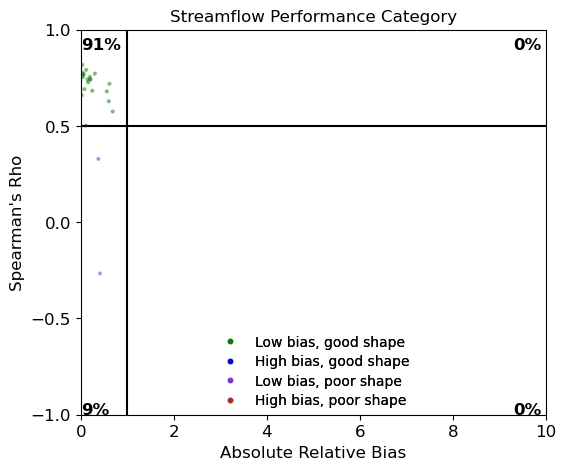

In [32]:
plot_utils.plot_condon_diagram(metrics_df, variable='streamflow')

## 6. Citations

Use `hf_hydrodata` to review the citation guidance for USGS observations used in this workflow.

In [24]:
hf.get_citations(dataset='usgs_nwis')

'Most U.S. Geological Survey (USGS) information resides in Public Domain and may be used without restriction, though they do ask that proper credit be given. An example credit statement would be: "(Product or data name) courtesy of the U.S. Geological Survey".\nSource: https://www.usgs.gov/information-policies-and-instructions/acknowledging-or-crediting-usgs'